### $$\underline{\text{DHF : Lab 3}}$$ 

##### $$\text{Arnaud Capitan, Achraf Ouboujemaa, Vasco Nappa}$$ 
___



### Librairies

In [1]:
import pandas as pd
import numpy as np
np.NaN = np.nan
import matplotlib.pyplot as plt
import Hawkes as hk
import time

___

### 1. Properties of Hawkes MLE estimates

#### Objective
In this section, we simulate a one-dimensional Hawkes process with constant intensity baseline $\mu$ and an exponential kernel $\nu(t) = \alpha e^{-\beta t}$. Our goal is to compute the Maximum Likelihood Estimators (MLE) on these simulated samples to empirically verify their theoretical statistical properties.

As seen in the course, the MLE estimator $\hat{\theta}_T = (\hat{\mu}, \hat{\alpha}, \hat{\beta})$ for a Hawkes process observed over a time horizon $T$ is expected to exhibit three key asymptotic properties:

* **Consistency**
* **Asymptotic Normality**
* **Asymptotic Efficiency**


We will use the library provided and will base our code on the tutorial available here: https://colab.research.google.com/github/omitakahiro/Hawkes/blob/master/notebooks/tutorial.ipynb

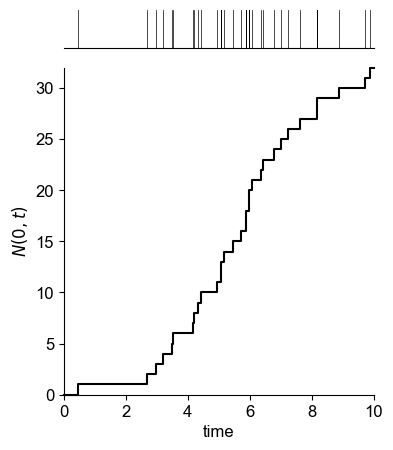

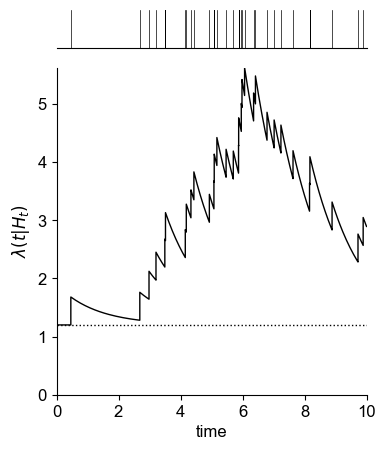

In [2]:
# Test of the library
para = {'mu':1.2, 'alpha':0.6, 'beta':0.8}
itv = [0,10]
model = hk.simulator().set_kernel('exp').set_baseline('const').set_parameter(para)
T = model.simulate(itv)
model.plot_N()
model.plot_l()

It does look like a self-excited linear process, as shown in course 4 slide 12

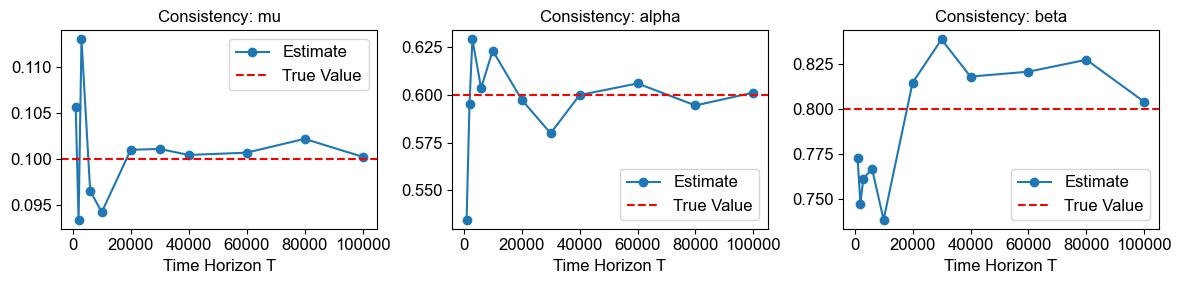

In [3]:
true_para = {'mu': 0.1, 'alpha': 0.6, 'beta': 0.8}

# Consistency
T_horizons = [1000,2000,3000,6000,10000,20000,30000,40000,60000,80000,100000]
results_cons = {'mu': [], 'alpha': [], 'beta': []}

for t_end in T_horizons:
    sim = hk.simulator().set_kernel('exp').set_baseline('const').set_parameter(true_para)
    #We simulate up to each horizon 
    T_sim = sim.simulate([0, t_end])
    
    est = hk.estimator().set_kernel('exp').set_baseline('const')
    est.fit(T_sim, [0, t_end])
    
    results_cons['mu'].append(est.parameter['mu'])
    results_cons['alpha'].append(est.parameter['alpha'])
    results_cons['beta'].append(est.parameter['beta'])

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, param in zip(axes, true_para.keys()):
    ax.plot(T_horizons, results_cons[param], marker='o', label='Estimate')
    ax.axhline(true_para[param], color='r', linestyle='--', label='True Value')
    ax.set_title(f'Consistency: {param}')
    ax.set_xlabel('Time Horizon T')
    ax.legend()
plt.tight_layout()
plt.show()


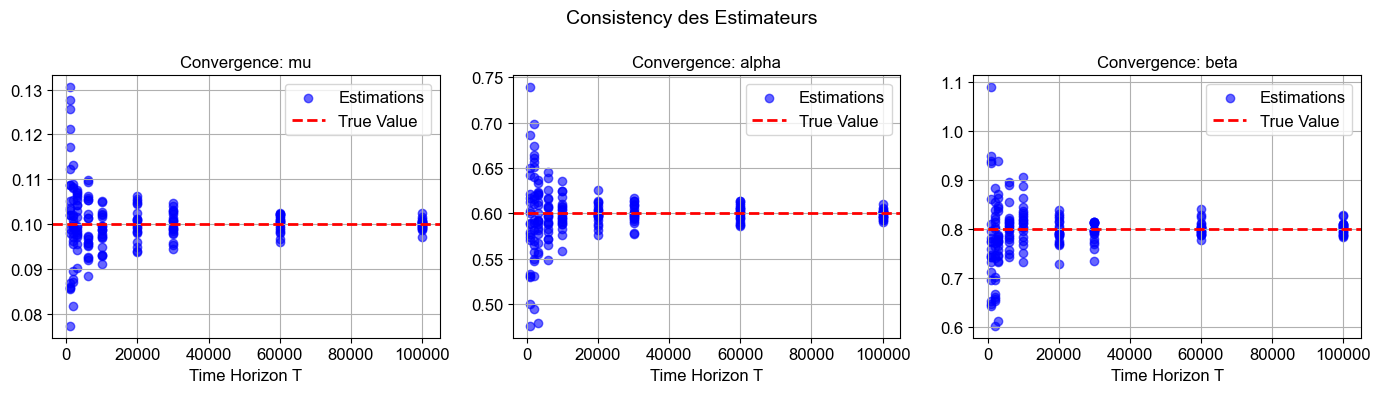

In [4]:
true_para = {'mu': 0.1, 'alpha': 0.6, 'beta': 0.8}

T_horizons = [1000,2000,3000,6000,10000,20000,30000,60000,100000]
N_sims = 20 


plot_data = {'T': [], 'mu': [], 'alpha': [], 'beta': []}


for t_end in T_horizons:
    for _ in range(N_sims):
        sim = hk.simulator().set_kernel('exp').set_baseline('const').set_parameter(true_para)
        T_sim = sim.simulate([0, t_end])
        
        est = hk.estimator().set_kernel('exp').set_baseline('const')
        est.fit(T_sim, [0, t_end])
        
        plot_data['T'].append(t_end)
        plot_data['mu'].append(est.parameter['mu'])
        plot_data['alpha'].append(est.parameter['alpha'])
        plot_data['beta'].append(est.parameter['beta'])

# --- Tracé des graphiques ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Consistency des Estimateurs', fontsize=14)

params_keys = ['mu', 'alpha', 'beta']
for i, param in enumerate(params_keys):
    ax = axes[i]
    # On trace tous les points sous forme de scatter (nuage)
    ax.scatter(plot_data['T'], plot_data[param], alpha=0.6, color='blue', label='Estimations')
    # Ligne de la vraie valeur
    ax.axhline(true_para[param], color='r', linestyle='--', linewidth=2, label='True Value')
    
    ax.set_title(f'Convergence: {param}')
    ax.set_xlabel('Time Horizon T')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

It looks like we have **consistency when T increases** : all the parameters seem to converge towards a limit and variance seems to reduce.

___

We now wish to test normality, by computing the histogram of estimated values and plotting Q-Q plots. We will also compute the p-value of the Shapiro-Wilk tests which uses as null hypothesis the normal distribution : we are expecting significant p-values $\geq 0.05$

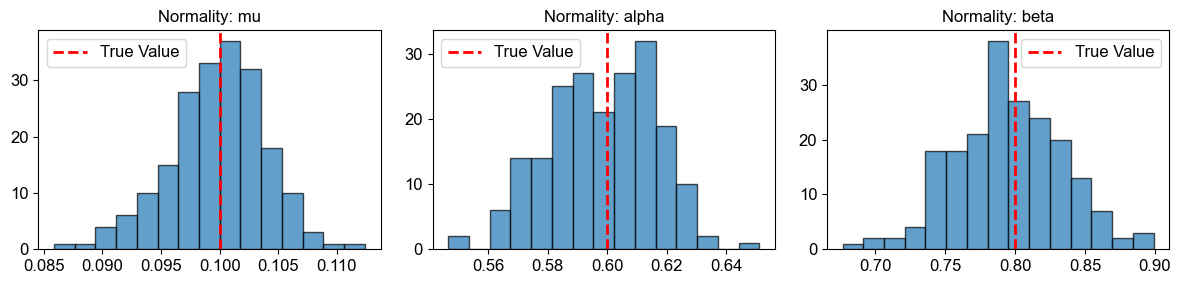

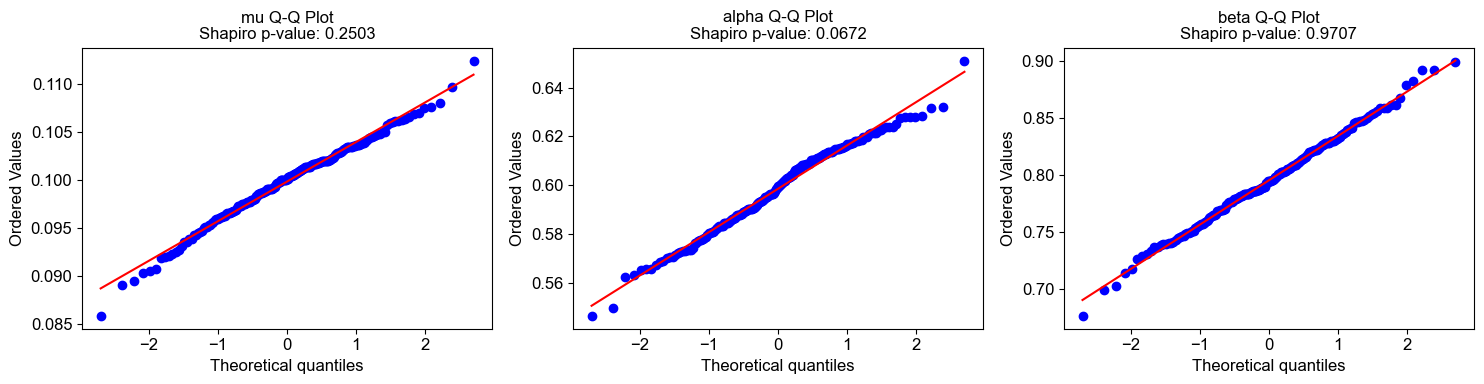

In [5]:
# Normality
N_sims = 200  # Number of paths to simulate
t_fixed = 10000
results_norm = {'mu': [], 'alpha': [], 'beta': []}

for _ in range(N_sims):
    sim = hk.simulator().set_kernel('exp').set_baseline('const').set_parameter(true_para)
    T_sim = sim.simulate([0, t_fixed])
    
    est = hk.estimator().set_kernel('exp').set_baseline('const')
    est.fit(T_sim, [0, t_fixed])
    
    results_norm['mu'].append(est.parameter['mu'])
    results_norm['alpha'].append(est.parameter['alpha'])
    results_norm['beta'].append(est.parameter['beta'])

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, param in zip(axes, true_para.keys()):
    ax.hist(results_norm[param], bins=15, edgecolor='black', alpha=0.7)
    ax.axvline(true_para[param], color='r', linestyle='dashed', linewidth=2, label='True Value')
    ax.set_title(f'Normality: {param}')
    ax.legend()
plt.tight_layout()
plt.show()

import scipy.stats as stats
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, param in zip(axes, true_para.keys()):
    data = results_norm[param]
    stats.probplot(data, dist="norm", plot=ax) # Generate Q-Q plot
    stat, p_value = stats.shapiro(data) # Perform Shapiro-Wilk test
    ax.set_title(f'{param} Q-Q Plot\nShapiro p-value: {p_value:.4f}')

plt.tight_layout()
plt.show()

Here we can see we have a pretty good Q-Q plot and the distributions are close to a normal distribution. 

Moreover we see that the Shapiro test p-values are all $ \geq 0.05$ which means we fail to reject the null hypothesis : $H_0 =$ {The data is normally distributed}

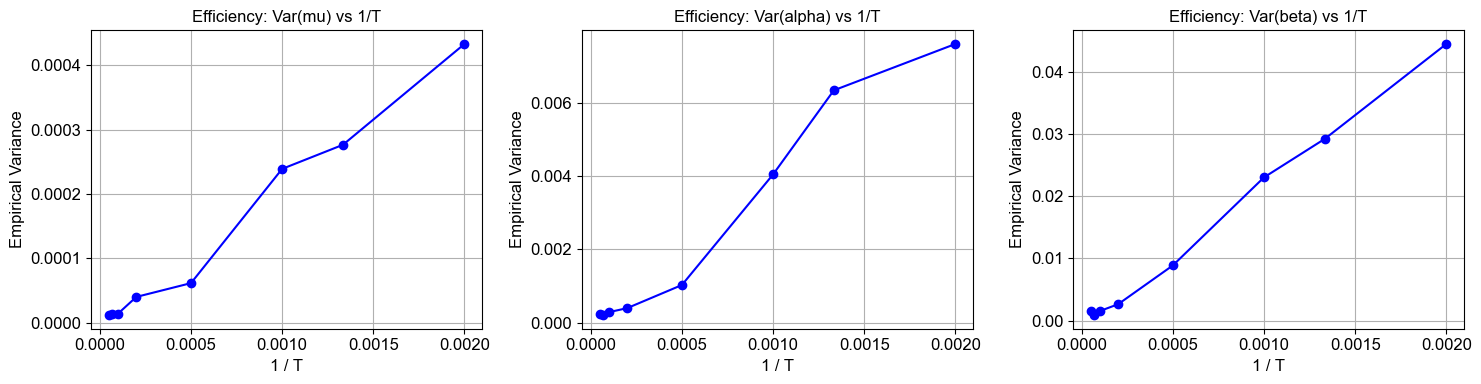

In [6]:
# Efficiency (Variance decay ~ 1/T)
T_list = [500, 750, 1000, 2000, 5000, 10000, 15000, 20000]
N_sims = 50
variances = {'mu': [], 'alpha': [], 'beta': []}

for t_end in T_list:
    est_mu, est_alpha, est_beta = [], [], []
    for _ in range(N_sims):
        sim = hk.simulator().set_kernel('exp').set_baseline('const').set_parameter(true_para)
        T_sim = sim.simulate([0, t_end])
        
        est = hk.estimator().set_kernel('exp').set_baseline('const')
        est.fit(T_sim, [0, t_end])
        
        est_mu.append(est.parameter['mu'])
        est_alpha.append(est.parameter['alpha'])
        est_beta.append(est.parameter['beta'])
        
    variances['mu'].append(np.var(est_mu))
    variances['alpha'].append(np.var(est_alpha))
    variances['beta'].append(np.var(est_beta))

# Plot Variance vs 1/T
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
inv_T = [1/t for t in T_list]

for ax, param in zip(axes, true_para.keys()):
    ax.plot(inv_T, variances[param], marker='o', linestyle='-', color='b')
    ax.set_title(f'Efficiency: Var({param}) vs 1/T')
    ax.set_xlabel('1 / T')
    ax.set_ylabel('Empirical Variance')
    ax.grid(True)

plt.tight_layout()
plt.show()

The plots above demonstrate a clear linear relationship between the empirical variance of our estimates ($\hat{\mu}$, $\hat{\alpha}$, $\hat{\beta}$) and $1/T$. This visual evidence confirms the **asymptotic efficiency** of the MLE: as the time horizon $T$ increases, the variance shrinks proportionally to $1/T$, matching the theoretical optimal rate bounded by the inverse Fisher Information matrix.

___

### 2. Computational cost of Hawkes simulators

#### Objective

In this section we will compute several simulation algorithms:
- Thinning
- Branching 

With several kernels:
- Exponential: $\nu(t) = \alpha e^{-\beta t}$
- Multiple exponential: $\nu(t) = \sum_{j=1}^{P} \alpha_{j} e^{-\beta_{j} t}$
- Power-law: $\nu(t) = \dfrac{\alpha}{(t+c)^\beta}$

#### 1. Thinning

In [7]:
def simulate_hawkes_thinning(mu, kernel_func, kernel_jump, T):
    t = 0
    events = []
    lambda_star = mu 
    while t < T:
        u = np.random.exponential(1.0 / lambda_star)
        t = t + u
        if t >= T:
            break
        # Compute actual intensity at time t
        lambda_t = mu + np.sum(kernel_func(t - np.array(events)))
        # Thinning
        D = np.random.uniform(0, 1)
        if D <= lambda_t / lambda_star:
            events.append(t)                     # Accept: add event
            lambda_star = lambda_t + kernel_jump # Update max intensity with the jump
        else:
            lambda_star = lambda_t               # Reject: just update decayed max intensity
            
    return np.array(events)


Kernel functions :

In [8]:
# 1. Exponential 
def exp_kernel(dt, alpha=0.4, beta=0.8):
    return alpha * np.exp(-beta * dt)
exp_jump = 0.4  # v(0) = alpha

# 2. Multiple Exponential  (here P=2)
def multi_exp_kernel(dt, alphas=np.array([0.3, 0.2]), betas=np.array([0.8, 1.4])):
    return alphas[0] * np.exp(-betas[0] * dt) + alphas[1] * np.exp(-betas[1] * dt)
multi_exp_jump = 0.3 + 0.2  # v(0) = sum(alphas)

# 3. Power-law
def power_law_kernel(dt, alpha=0.3, beta=1.5, c=1.2):
    return alpha / ((dt + c) ** beta)
power_law_jump = 0.3 / (1.2 ** 1.5)  # v(0) = alpha / c^beta

Simulation :

In [9]:
mu_baseline = 0.2
T_sim = 100

events_exp = simulate_hawkes_thinning(mu_baseline, exp_kernel, exp_jump, T_sim)
events_m_exp = simulate_hawkes_thinning(mu_baseline, multi_exp_kernel, multi_exp_jump, T_sim)
events_pow = simulate_hawkes_thinning(mu_baseline, power_law_kernel, power_law_jump, T_sim)

print(f"Number of events (Exponential): {len(events_exp)}")
print(f"Number of events (Multi-Exp): {len(events_m_exp)}")
print(f"Number of events (Power-law): {len(events_pow)}")

Number of events (Exponential): 42
Number of events (Multi-Exp): 41
Number of events (Power-law): 30


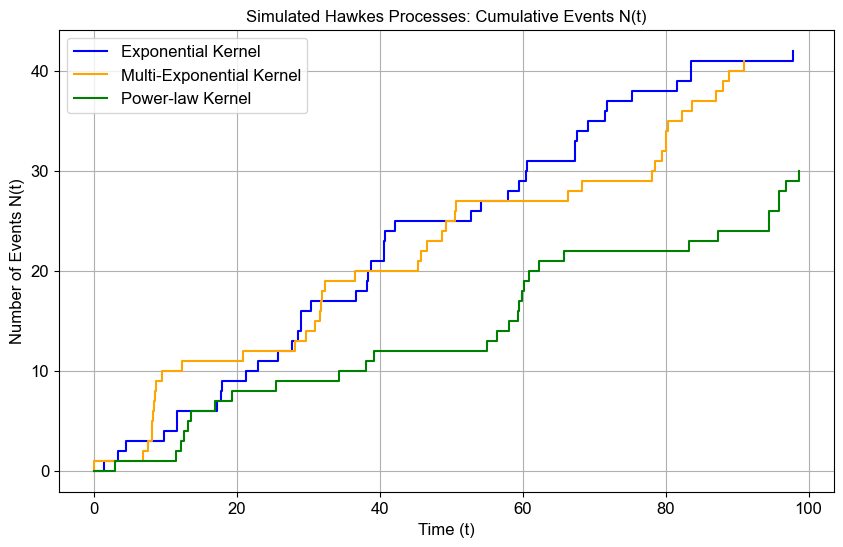

In [10]:
plt.figure(figsize=(10, 6))

# Plots
plt.step(np.insert(events_exp, 0, 0), np.arange(len(events_exp) + 1), where='post', label='Exponential Kernel', color='blue')
plt.step(np.insert(events_m_exp, 0, 0), np.arange(len(events_m_exp) + 1), where='post', label='Multi-Exponential Kernel', color='orange')
plt.step(np.insert(events_pow, 0, 0), np.arange(len(events_pow) + 1), where='post', label='Power-law Kernel', color='green')

plt.title('Simulated Hawkes Processes: Cumulative Events N(t)')
plt.xlabel('Time (t)')
plt.ylabel('Number of Events N(t)')
plt.legend()
plt.grid(True)
plt.show()

We will now measure the time complexity of the thinning algorithm for different kernels. The above implementation requires the past events for each new iteration, so the complexity is in $O(n^2)$. We will also compute below for the exponential $O(n)$ method as seen during the course.

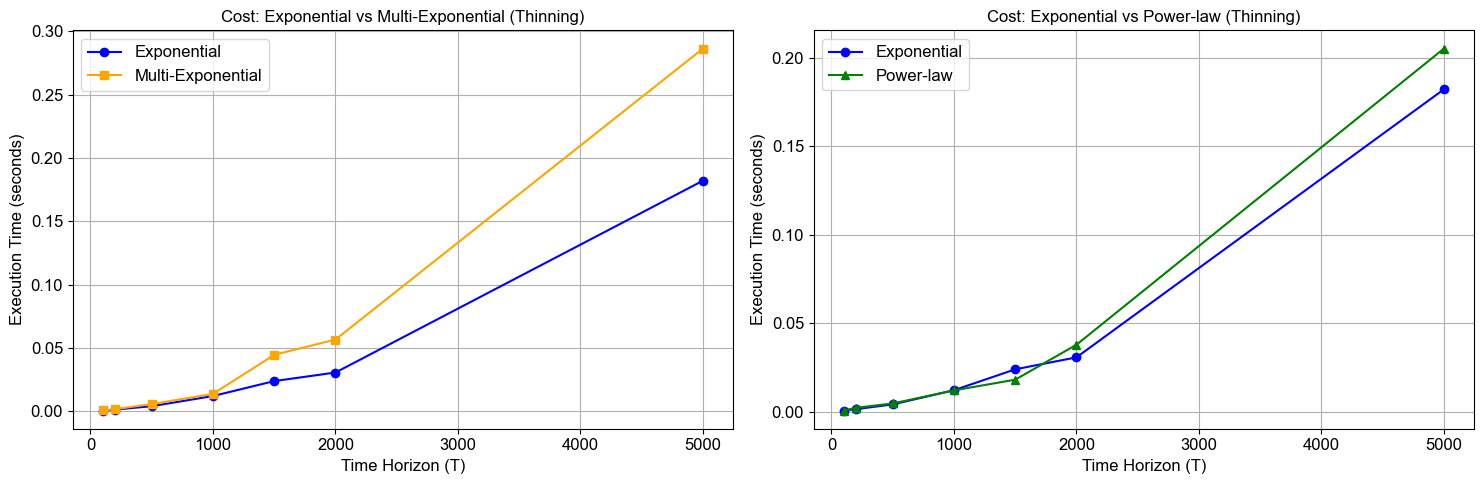

In [11]:
T_values = [100, 200, 500, 1000, 1500, 2000, 5000]

times_exp, times_m_exp, times_pow = [], [], []
N_events_exp, N_events_m_exp, N_events_pow = [], [], []

for T_sim in T_values:
    # Exponential Kernel
    start_time = time.perf_counter()
    ev_exp = simulate_hawkes_thinning(mu_baseline, exp_kernel, exp_jump, T_sim)
    times_exp.append(time.perf_counter() - start_time)
    N_events_exp.append(len(ev_exp))
    
    # Multi-Exponential Kernel
    start_time = time.perf_counter()
    ev_m_exp = simulate_hawkes_thinning(mu_baseline, multi_exp_kernel, multi_exp_jump, T_sim)
    times_m_exp.append(time.perf_counter() - start_time)
    N_events_m_exp.append(len(ev_m_exp))
    
    # Power-law Kernel
    start_time = time.perf_counter()
    ev_pow = simulate_hawkes_thinning(mu_baseline, power_law_kernel, power_law_jump, T_sim)
    times_pow.append(time.perf_counter() - start_time)
    N_events_pow.append(len(ev_pow))


fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(T_values, times_exp, marker='o', label='Exponential', color='blue')
axes[0].plot(T_values, times_m_exp, marker='s', label='Multi-Exponential', color='orange')
axes[0].set_title('Cost: Exponential vs Multi-Exponential (Thinning)')
axes[0].set_xlabel('Time Horizon (T)')
axes[0].set_ylabel('Execution Time (seconds)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(T_values, times_exp, marker='o', label='Exponential', color='blue')
axes[1].plot(T_values, times_pow, marker='^', label='Power-law', color='green')
axes[1].set_title('Cost: Exponential vs Power-law (Thinning)')
axes[1].set_xlabel('Time Horizon (T)')
axes[1].set_ylabel('Execution Time (seconds)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

We can see on the graphs that the computing time is $O(n^2)$ for the algorithms.

Those results were expected, as our naive algorithm computes each iteration using all the past steps, which results in a $O(n^2)$ complexity. The multi-exponential kernel is following the same trend as the exponential kernel but is still slower as it requires more terms to compute.

To fix this issue on the exponential kernel, we will be using the method seen during the course : instead of iterating on all past events, we can recursively update the intensity at every jump. It reduces the complexity to $O(n)$

In [12]:
def simulate_hawkes_optimized_exp(mu, alpha, beta, T):
    t = 0.0
    events = []
    S = 0.0 # We maintain a running sum 'S' of the kernel excitations
    t_last = 0.0
    lambda_star = mu
    while t < T:
        # Candidate generation
        u = np.random.exponential(1/lambda_star)
        t = t + u
        if t >= T:
            break
        # Compute exact intensity at time t using the recursive decay
        decay = np.exp(-beta * (t - t_last))
        lambda_t = mu + S * decay
        
        # Thinning step
        D = np.random.uniform(0, 1)
        if D <= lambda_t / lambda_star: # Accept: add event and update our running history sum
            events.append(t)
            S = S * decay + alpha  
            t_last = t             
            lambda_star = lambda_t + alpha
        else: # Reject: just update the bounding intensity
            lambda_star = lambda_t
    return np.array(events)

# Quick timing check to compare with the naive one
start_time = time.perf_counter()
ev_opt = simulate_hawkes_optimized_exp(mu=0.2, alpha=0.6, beta=0.8, T=1200)
opt_time = time.perf_counter() - start_time

print(f"Optimized Exponential Execution Time: {opt_time:.5f} seconds")

Optimized Exponential Execution Time: 0.00739 seconds


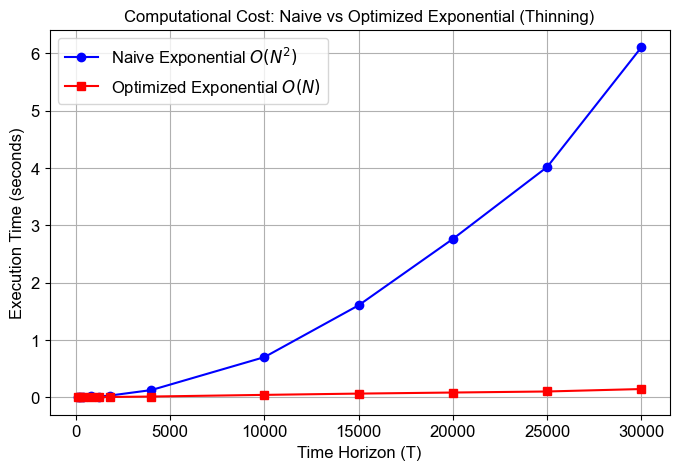

In [13]:
times_opt_exp = []
times_exp = []     
N_events_exp = []

T_values = [100, 200, 400, 800, 1200, 1800, 4000, 10000,15000,20000,25000,30000]
for T_sim in T_values:
    start_time = time.perf_counter()
    _ = simulate_hawkes_optimized_exp(mu=0.2, alpha=0.6, beta=0.8, T=T_sim)
    times_opt_exp.append(time.perf_counter() - start_time)
    start_time = time.perf_counter()
    ev_exp = simulate_hawkes_thinning(mu_baseline, exp_kernel, exp_jump, T_sim)
    times_exp.append(time.perf_counter() - start_time)
    N_events_exp.append(len(ev_exp))

plt.figure(figsize=(8, 5))
plt.plot(T_values, times_exp, marker='o', label='Naive Exponential $O(N^2)$', color='blue')
plt.plot(T_values, times_opt_exp, marker='s', label='Optimized Exponential $O(N)$', color='red')
plt.title('Computational Cost: Naive vs Optimized Exponential (Thinning)')
plt.xlabel('Time Horizon (T)')
plt.ylabel('Execution Time (seconds)')
plt.legend()
plt.grid(True)
plt.show()

This graph proves the usefulness of optimizing the algorithm. The naive approach has an computing-time increasing drastically with complexity in $O(N^2)$, whereas the optimized implementation uses the memoryless result of the exponential kernel to update recursively the intensity. As a result, the complexity falls back to $O(N)$ and the computing time remains low and linear as a function of the time horizon.

#### Branching

In [14]:
def simulate_hawkes_branching(mu, n_branching, sample_offspring_func, T):
    # Simulate Immigrants (Background events with homogeneous Poisson process)
    immigrants = []
    t = 0.0
    while True:
        t += np.random.exponential(1.0 / mu)
        if t >= T:
            break
        immigrants.append(t)    
    events = list(immigrants)
    unprocessed = list(immigrants)
    
    # Simulate Offspring generation by generation
    while unprocessed:
        parent_t = unprocessed.pop(0)
        num_children = np.random.poisson(n_branching) # Draw number of children for this parent (Poisson distributed with mean = integral of kernel)
        for _ in range(num_children):
            dt = sample_offspring_func()
            child_t = parent_t + dt
            if child_t < T:
                events.append(child_t)
                unprocessed.append(child_t) # The child becomes a parent for the next generation
                
    return np.sort(np.array(events))

Kernels

In [15]:
# Exponential (alpha=0.5, beta=1.2)
n_exp = 0.5 / 1.2 # Integral: alpha/beta
def sample_exp():
    return np.random.exponential(1 / 1.2) # Sample from exponential density

# Multiple Exponential (alphas=[0.3, 0.2], betas=[1.4, 1.8])
n1, n2 = 0.3/1.4, 0.2/1.8
n_multi_exp = n1 + n2
def sample_multi_exp():
    # Mix of two exponentials
    if np.random.uniform() < (n1 / n_multi_exp):
        return np.random.exponential(1.0 / 1.4)
    else:
        return np.random.exponential(1.0 / 1.8)

# Power-law (alpha=0.6, beta=1.5, c=1.2) -> changed alpha for stability
# Integral: alpha / ((beta-1)*c**(beta-1))
n_power_law = 0.6 / ((1.5 - 1.0) * (1.2 ** 0.5)) 
def sample_power_law():
    # Inverse transform sampling for Power-law density
    U = np.random.uniform(0, 1)
    return 1.2 * (U**(-1.0 / 0.5) - 1.0) 

Simulations

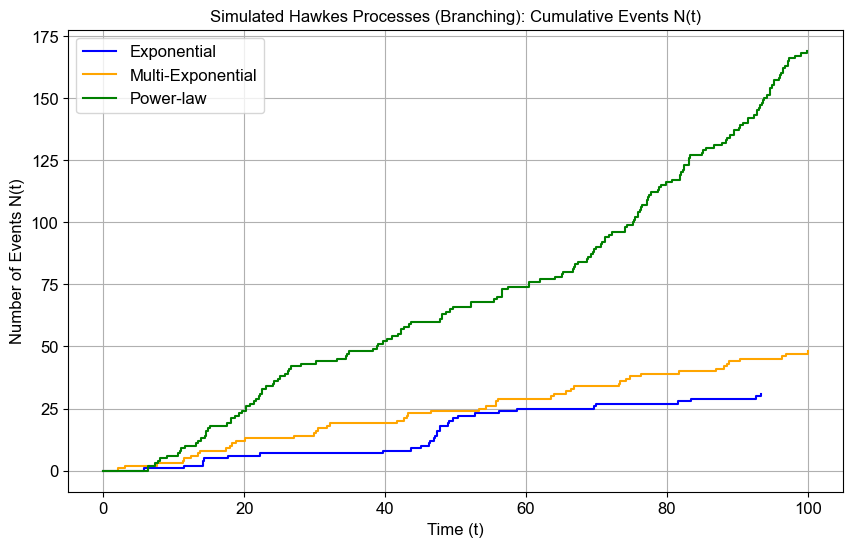

In [16]:
mu_baseline = 0.2
T_sim = 100

events_exp_b = simulate_hawkes_branching(mu_baseline, n_exp, sample_exp, T_sim)
events_m_exp_b = simulate_hawkes_branching(mu_baseline, n_multi_exp, sample_multi_exp, T_sim)
events_pow_b = simulate_hawkes_branching(mu_baseline, n_power_law, sample_power_law, T_sim)

plt.figure(figsize=(10, 6))
plt.step(np.insert(events_exp_b, 0, 0), np.arange(len(events_exp_b) + 1), where='post', label='Exponential', color='blue')
plt.step(np.insert(events_m_exp_b, 0, 0), np.arange(len(events_m_exp_b) + 1), where='post', label='Multi-Exponential', color='orange')
plt.step(np.insert(events_pow_b, 0, 0), np.arange(len(events_pow_b) + 1), where='post', label='Power-law', color='green')

plt.title('Simulated Hawkes Processes (Branching): Cumulative Events N(t)')
plt.xlabel('Time (t)')
plt.ylabel('Number of Events N(t)')
plt.legend()
plt.grid(True)
plt.show()

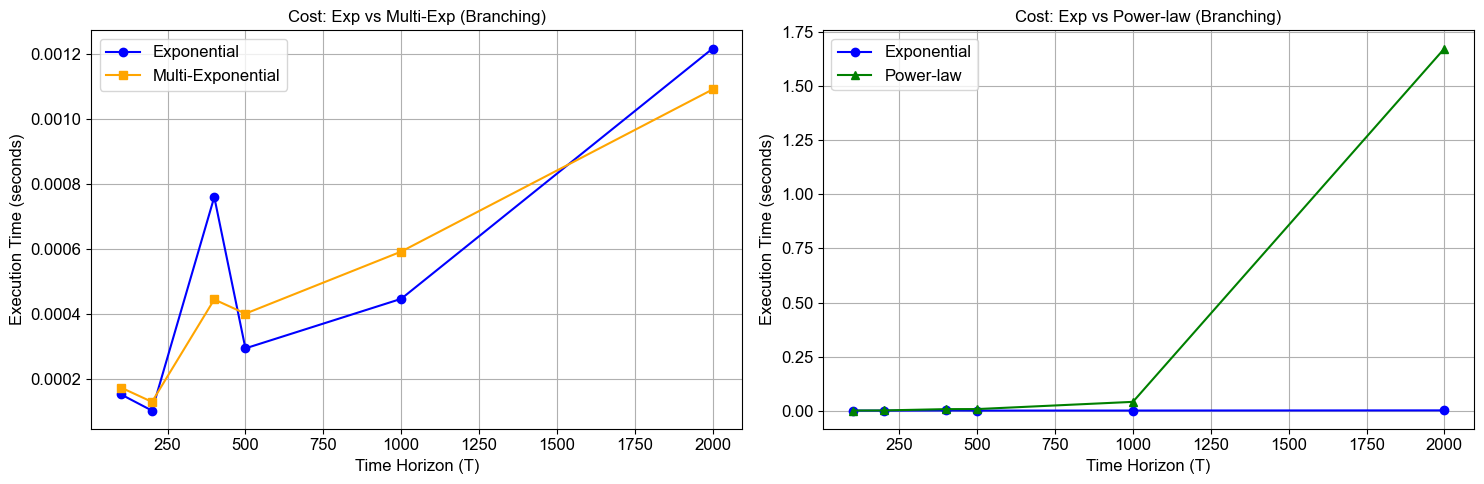

In [17]:
T_values_b = [100, 200, 400, 500, 1000, 2000]

times_exp_b, times_m_exp_b, times_pow_b = [], [], []

for T_sim in T_values_b:
    # Exponential
    start_time = time.perf_counter()
    _ = simulate_hawkes_branching(mu_baseline, n_exp, sample_exp, T_sim)
    times_exp_b.append(time.perf_counter() - start_time)
    
    # Multi-Exponential
    start_time = time.perf_counter()
    _ = simulate_hawkes_branching(mu_baseline, n_multi_exp, sample_multi_exp, T_sim)
    times_m_exp_b.append(time.perf_counter() - start_time)
    
    # Power-law
    start_time = time.perf_counter()
    _ = simulate_hawkes_branching(mu_baseline, n_power_law, sample_power_law, T_sim)
    times_pow_b.append(time.perf_counter() - start_time)


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(T_values_b, times_exp_b, marker='o', label='Exponential', color='blue')
axes[0].plot(T_values_b, times_m_exp_b, marker='s', label='Multi-Exponential', color='orange')
axes[0].set_title('Cost: Exp vs Multi-Exp (Branching)')
axes[0].set_xlabel('Time Horizon (T)')
axes[0].set_ylabel('Execution Time (seconds)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(T_values_b, times_exp_b, marker='o', label='Exponential', color='blue')
axes[1].plot(T_values_b, times_pow_b, marker='^', label='Power-law', color='green')
axes[1].set_title('Cost: Exp vs Power-law (Branching)')
axes[1].set_xlabel('Time Horizon (T)')
axes[1].set_ylabel('Execution Time (seconds)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

We can see that the performance of the branching algorithm is roughly $O(n)$ for exponential and multi-exponential kernels, but is much higher for power-law, seemingly $O(n^2)$.

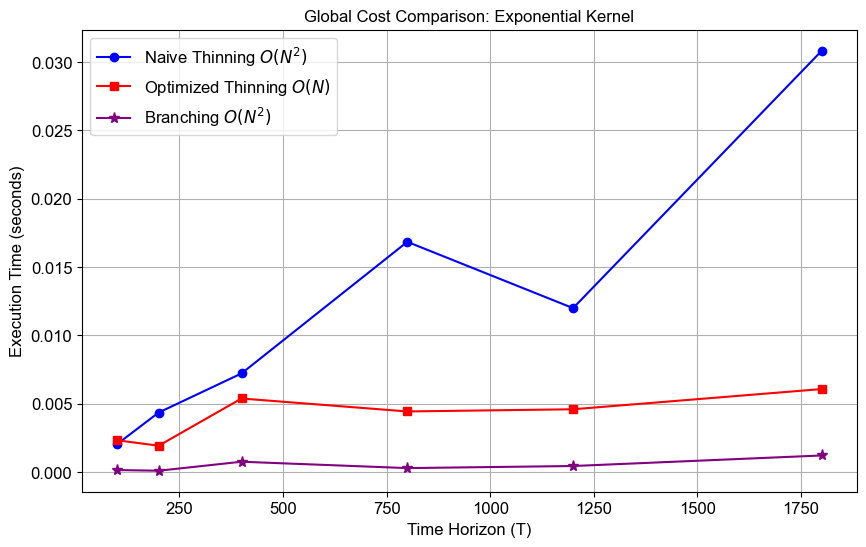

In [ ]:
plt.figure(figsize=(10, 6))

n_points = min(len(T_values), len(times_exp), len(times_opt_exp), len(times_exp_b))

# Standard thinning O(N^2)
plt.plot(T_values[:n_points], times_exp[:n_points], 
         marker='o', label='Naive Thinning $O(N^2)$', color='blue')

# Optimized thinning O(N)
plt.plot(T_values[:n_points], times_opt_exp[:n_points], 
         marker='s', label='Optimized Thinning $O(N)$', color='red')

# Branching O(N)
plt.plot(T_values[:n_points], times_exp_b[:n_points], 
         marker='*', markersize=8, label='Branching $O(N)$', color='purple')

plt.title("Global Cost Comparison: Exponential Kernel")
plt.xlabel("Time Horizon (T)")
plt.ylabel("Execution Time (seconds)")
plt.legend()
plt.grid(True)
plt.show()

The naive thinning approach has a quadratic increase of time execution $O(N^2)$ due to the iteration over the previous steps. On the contrary, the optimized thinning and the branching algorithms have a linear complexity $O(N)$, and their execution time remain small and almost identical even for high time horizons.

___

#### Visual Goodness of Fit

Like seen in class we can check if our simulations are correct using the chnage of time theorem

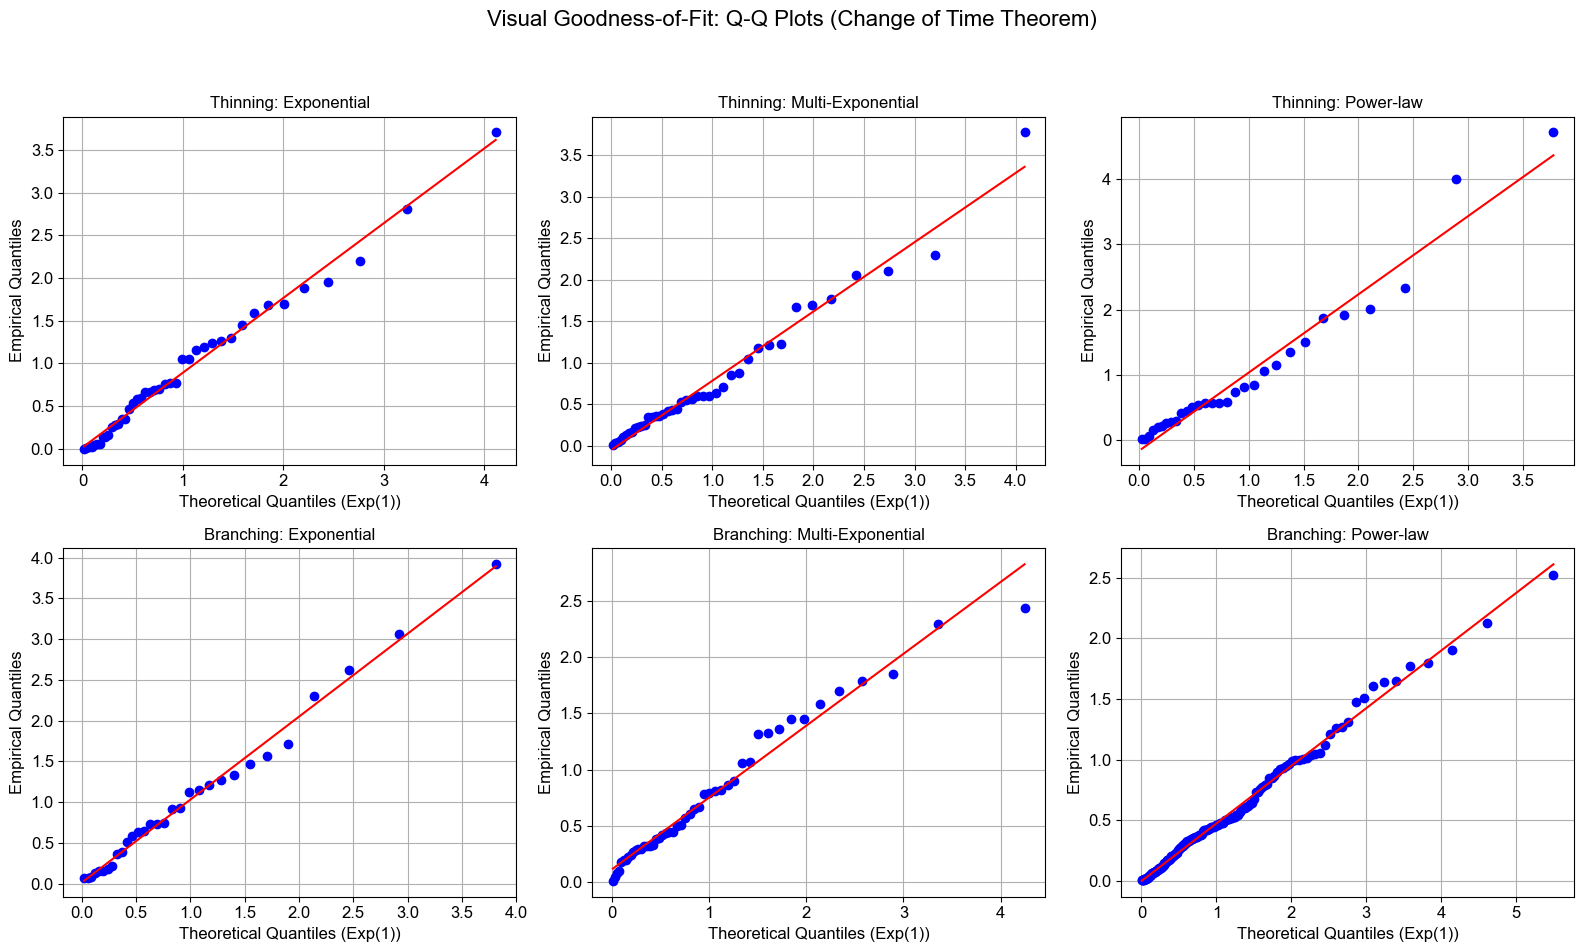

In [19]:
def compute_tau(events, mu, kernel_name, **kwargs): #Compute Lambda(t_i) - Lambda(t_{i-1}) for each event t_i
    
    N = len(events)
    if N == 0: return np.array([])
        
    Lambda = np.zeros(N)
    
    for i in range(N):
        t_i = events[i]
        dt = t_i - events[:i] # Time differences with all past events
        
        # Analytical integral of the kernel
        if kernel_name == 'exp':
            alpha, beta = kwargs['alpha'], kwargs['beta']
            V = (alpha / beta) * (1 - np.exp(-beta * dt))
            
        elif kernel_name == 'multi_exp':
            alphas, betas = kwargs['alphas'], kwargs['betas']
            V = (alphas[0] / betas[0]) * (1 - np.exp(-betas[0] * dt)) + \
                (alphas[1] / betas[1]) * (1 - np.exp(-betas[1] * dt))
                
        elif kernel_name == 'power_law':
            alpha, beta_param, c = kwargs['alpha'], kwargs['beta'], kwargs['c']
            # Integral of alpha / (t+c)^beta
            V = (alpha / (beta_param - 1)) * (c**(1 - beta_param) - (dt + c)**(1 - beta_param))
            
        Lambda[i] = mu * t_i + np.sum(V)
        
    # tau_i are the increments of the Lambda(t)
    tau = np.zeros(N)
    tau[0] = Lambda[0]
    tau[1:] = np.diff(Lambda)
    
    return tau

# Compute tau for all 6 methods (3 thinning + 3 branching)

# 1. Thinning
tau_exp_t = compute_tau(events_exp, mu=0.2, kernel_name='exp', alpha=0.5, beta=1.2)
tau_m_exp_t = compute_tau(events_m_exp, mu=0.2, kernel_name='multi_exp', alphas=[0.3, 0.2], betas=[1.4, 1.8])
tau_pow_t = compute_tau(events_pow, mu=0.2, kernel_name='power_law', alpha=0.25, beta=1.5, c=1.2)

# 2. Branching
tau_exp_b = compute_tau(events_exp_b, mu=0.2, kernel_name='exp', alpha=0.5, beta=1.2)
tau_m_exp_b = compute_tau(events_m_exp_b, mu=0.2, kernel_name='multi_exp', alphas=[0.3, 0.2], betas=[1.4, 1.8])
tau_pow_b = compute_tau(events_pow_b, mu=0.2, kernel_name='power_law', alpha=0.25, beta=1.5, c=1.2)

# QQ Plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Visual Goodness-of-Fit: Q-Q Plots (Change of Time Theorem)', fontsize=16)

# Row 1: Thinning
stats.probplot(tau_exp_t, dist="expon", plot=axes[0, 0])
axes[0, 0].set_title('Thinning: Exponential')

stats.probplot(tau_m_exp_t, dist="expon", plot=axes[0, 1])
axes[0, 1].set_title('Thinning: Multi-Exponential')

stats.probplot(tau_pow_t, dist="expon", plot=axes[0, 2])
axes[0, 2].set_title('Thinning: Power-law')

# Row 2: Branching
stats.probplot(tau_exp_b, dist="expon", plot=axes[1, 0])
axes[1, 0].set_title('Branching: Exponential')

stats.probplot(tau_m_exp_b, dist="expon", plot=axes[1, 1])
axes[1, 1].set_title('Branching: Multi-Exponential')

stats.probplot(tau_pow_b, dist="expon", plot=axes[1, 2])
axes[1, 2].set_title('Branching: Power-law')

for ax in axes.flatten():
    ax.set_xlabel('Theoretical Quantiles (Exp(1))')
    ax.set_ylabel('Empirical Quantiles')
    ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

These plots seem to confirm that our simulations are indeed correct.

### 3. MLE vs EM estimation

For the MLE estimation we will be simply using the library available.

For the EM estimation we will code the algorithm for Hawkes process seen in class (Slides 30-33)

In [48]:
def em_hawkes_exp(events, T_end, init_params, n_iter=30):
    mu, alpha, beta = init_params
    
    N = len(events)
    if N == 0:
        return mu, alpha, beta
    
    events = np.array(events)
    dt_matrix = events.reshape(-1, 1) - events.reshape(1, -1)
    mask = dt_matrix > 0 
    
    for _ in range(n_iter):
        # Kernel evaluations for all pairs
        kernel_matrix = np.zeros((N, N))
        kernel_matrix[mask] = alpha * np.exp(-beta * dt_matrix[mask])
        
        # Total intensity at each event time t_j
        lambda_t = mu + np.sum(kernel_matrix, axis=1)
        
        # Latent probabilities
        p_jj = mu / lambda_t  # Probability that event j is background
        
        p_ij = kernel_matrix / lambda_t.reshape(-1, 1) 
        
        # M-STEP 
        sum_pij = np.sum(p_ij[mask]) 
        sum_pij_dt = np.sum((p_ij * dt_matrix)[mask])
        
        mu = np.sum(p_jj) / T_end # mu update
        beta = sum_pij / sum_pij_dt if sum_pij_dt > 0 else beta # beta update
        
        survival = np.sum(1.0 - np.exp(-beta * (T_end - events)))
        alpha = beta*sum_pij / survival if survival > 0 else alpha # alpha update
        
    return mu, alpha/beta, beta

# Estimation
true_para = {'mu': 0.2, 'alpha': 0.3, 'beta': 0.7}
init_params = [0.1, 0.1, 0.5]


T_list = [500,1000,2000,3000] 
N_sims = 20  # Number of paths per T to observe variance

results_mle = {'T': [], 'time': [], 'mu': [], 'alpha': [], 'beta': []}
results_em = {'T': [], 'time': [], 'mu': [], 'alpha': [], 'beta': []}


for T_end in T_list:
    
    for _ in range(N_sims):
        # 1. Simulate Path
        sim = hk.simulator().set_kernel('exp').set_baseline('const').set_parameter(true_para)
        T_sim = sim.simulate([0, T_end])
        
        #Ensure we have enough events to estimate
        if len(T_sim) < 10:
            continue
            
        # 2. MLE Estimation (using the Library)
        t0 = time.perf_counter()
        est_mle = hk.estimator().set_kernel('exp').set_baseline('const')
        est_mle.fit(T_sim, [0, T_end])
        results_mle['time'].append(time.perf_counter() - t0)
        results_mle['mu'].append(est_mle.parameter['mu'])
        results_mle['alpha'].append(est_mle.parameter['alpha'])
        results_mle['beta'].append(est_mle.parameter['beta'])
        results_mle['T'].append(T_end)
        
        # 3. EM Estimation
        t0 = time.perf_counter()
        mu_em, alpha_em, beta_em = em_hawkes_exp(T_sim, T_end, init_params, n_iter=20)
        results_em['time'].append(time.perf_counter() - t0)
        results_em['mu'].append(mu_em)
        results_em['alpha'].append(alpha_em)
        results_em['beta'].append(beta_em)
        results_em['T'].append(T_end)


<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Arnaud\AppData\Local\Temp\ipykernel_18696\1928658535.py:16: SyntaxWarning: invalid escape sequence '\m'
  titles = ['Convergence of $\mu$', 'Convergence of $\\alpha$', 'Convergence of $\\beta$']


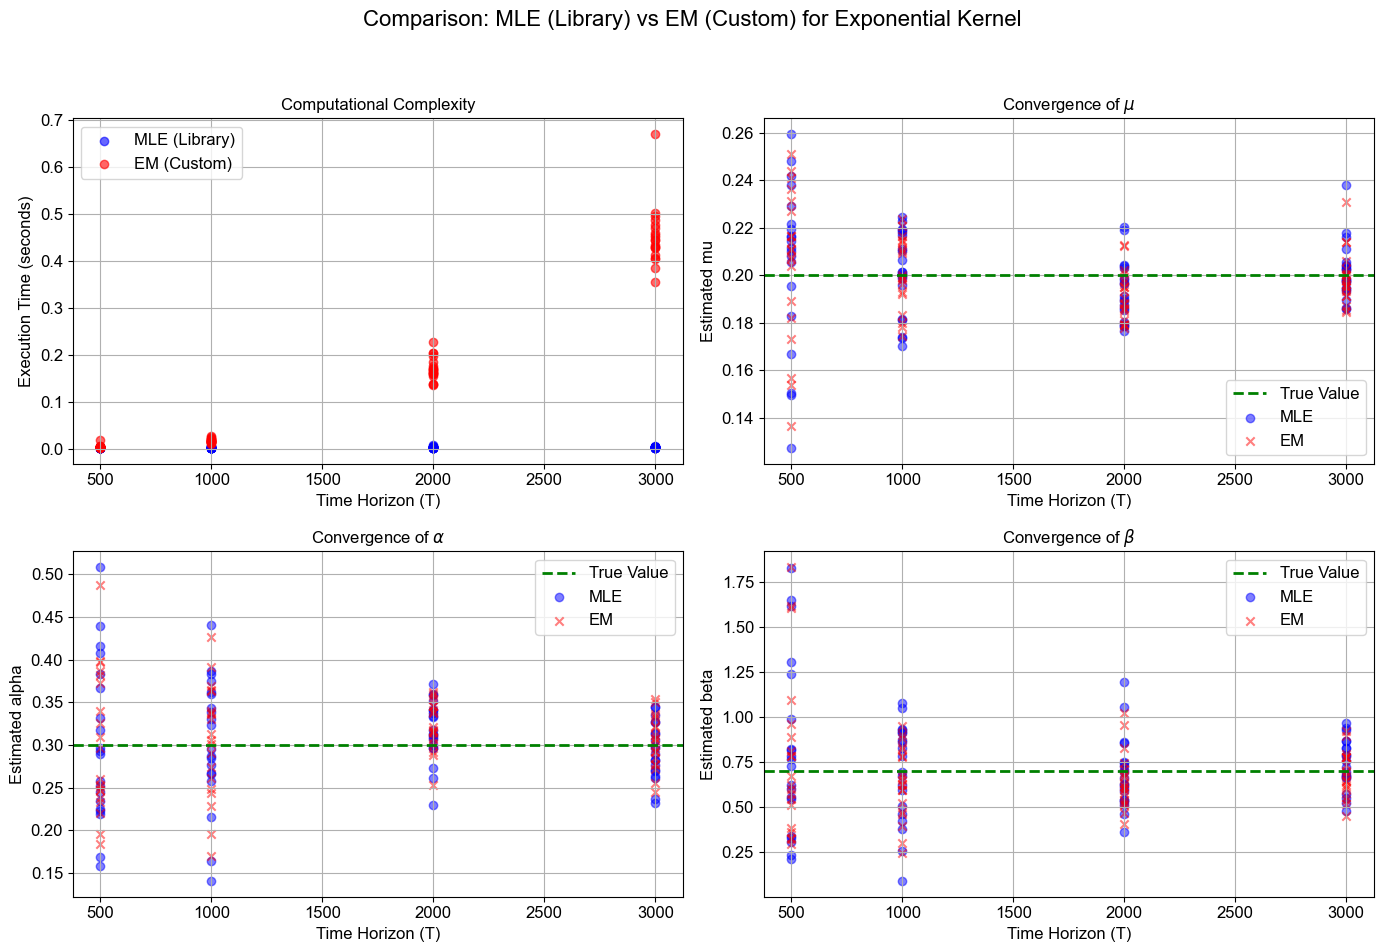

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparison: MLE (Library) vs EM (Custom) for Exponential Kernel', fontsize=16)

# 1. Computational Complexity
axes[0, 0].scatter(results_mle['T'], results_mle['time'], label='MLE (Library)', color='blue', alpha=0.6)
axes[0, 0].scatter(results_em['T'], results_em['time'], label='EM (Custom)', color='red', alpha=0.6)
axes[0, 0].set_title('Computational Complexity')
axes[0, 0].set_xlabel('Time Horizon (T)')
axes[0, 0].set_ylabel('Execution Time (seconds)')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Parameter Convergence Plots
params = ['mu', 'alpha', 'beta']
true_vals = [true_para['mu'], true_para['alpha'], true_para['beta']]
titles = ['Convergence of $\mu$', 'Convergence of $\\alpha$', 'Convergence of $\\beta$']

for i, param in enumerate(params):
    ax = axes[(i+1)//2, (i+1)%2]
    # Plot true value line
    ax.axhline(true_vals[i], color='green', linestyle='--', label='True Value', linewidth=2)
    
    # Scatter plot estimates
    ax.scatter(results_mle['T'], results_mle[param], label='MLE', color='blue', alpha=0.5, marker='o')
    ax.scatter(results_em['T'], results_em[param], label='EM', color='red', alpha=0.5, marker='x')
    
    ax.set_title(titles[i])
    ax.set_xlabel('Time Horizon (T)')
    ax.set_ylabel(f'Estimated {param}')
    ax.legend()
    ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Statistical Convergence: Both estimators demonstrate clear consistency. As the time horizon T increases, the variance of the estimates shrinks, and the points tightly converge around the true parameter values. Notably, MLE and EM yield nearly identical parameter estimates, as seen by the overlapping red crosses and blue dots.

Computational Complexity: The computational bottleneck of the EM algorithm is visible. While the MLE scales efficiently with linear complexity, the custom EM algorithm execution time growth seems quadratically. This highlights the heavy cost of computing the latent probability matrix for large datasets.